# 04 - Explainability
## Give Me Some Credit - Loan Default Prediction
The final model (XGBoost, ROC-AUC 0.868, PR-AUC 0.394 on validation, from `03_model_evaluation.ipynb`) is accurate enough to use, but "accurate" isn't the same as "explainable" and in in a credit risk setting, explainability isn't optional. Lenders are typically required to be able to state *why* an applicant was denied (adverse action notices under ECOA in the US, for example), and a portfolio project that stops at "here's the AUC" misses that this is a domain where interpretability is part of the actual job, not a nice-to-have. </br>
This notebook uses SHAP (SHapley Additive exPlanations) to answer two questions: </br>
1. **Globaly** - across all applicants, which features drive the model's predictions the most?
2. **Locally** - for one specific applicant, why did the model predict what it predicted?

In [1]:
import sys
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

sys.path.append(str(Path("..") / "src"))
from pipeline import ALL_FEATURES, CATEGORICAL_FEATURES, NUMERIC_FEATURES, TARGET

pd.set_option("display.max_columns", None)
shap.initjs()

## 1. Load the saved pipeline and validation data

In [2]:
pipeline = joblib.load("../models/model.joblib")
val_df = pd.read_csv("../data/processed/val.csv")

X_val = val_df[ALL_FEATURES]
y_val = val_df[TARGET]

preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]
X_val.shape

(30000, 15)

## 2. Transform validation data and recover feature names
SHAP needs to explain the model on the *preprocessed* features (after scaling and one-hot encoding), not the raw ones, so I will transform `X_val` through the pipeline's preprocessor and pull the resulting column names out of the `ColumnTransformer` directly, rather than hardcoding them, so this stays correct if the feature set changes later.

In [5]:
X_val_transformed = preprocessor.transform(X_val)

#recover feature names: numeric features pass through unchanged, categorical features get expanded by OneHotEncoder into one column per category
cat_encoder = preprocessor.named_transformers_["cat"].named_steps["one-hot"]
cat_feature_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES)
all_feature_names = list(NUMERIC_FEATURES) + list(cat_feature_names)

X_val_transformed_df = pd.DataFrame(X_val_transformed, columns=all_feature_names)
X_val_transformed_df.shape

(30000, 17)

## 3. Build the SHAP explainer
XGBoost is a tree model, so `TreeExplainer` is the right choice - it's exact (not an approximation like `KernelExplainer`) and fast even on thousands of rows.
Using a sample of the validation set rather than all 30,000 rows to keep this notebook fast to run; increase `SAMPLE_SIZE` if you want the full set and have to spare.

In [7]:
SAMPLE_SIZE = 30000
sample_idx = np.random.RandomState(42).choice(
    len(X_val_transformed_df), size=SAMPLE_SIZE, replace=False
)
X_sample = X_val_transformed_df.iloc[sample_idx]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

## 4. Global feature importance - beeswarm plot
Each point is one applicant. Position on the x-axis shows whether the feature pushed the prediction toward higher or lower default risk for that applicant; color shows whether the feature's value was high or low.

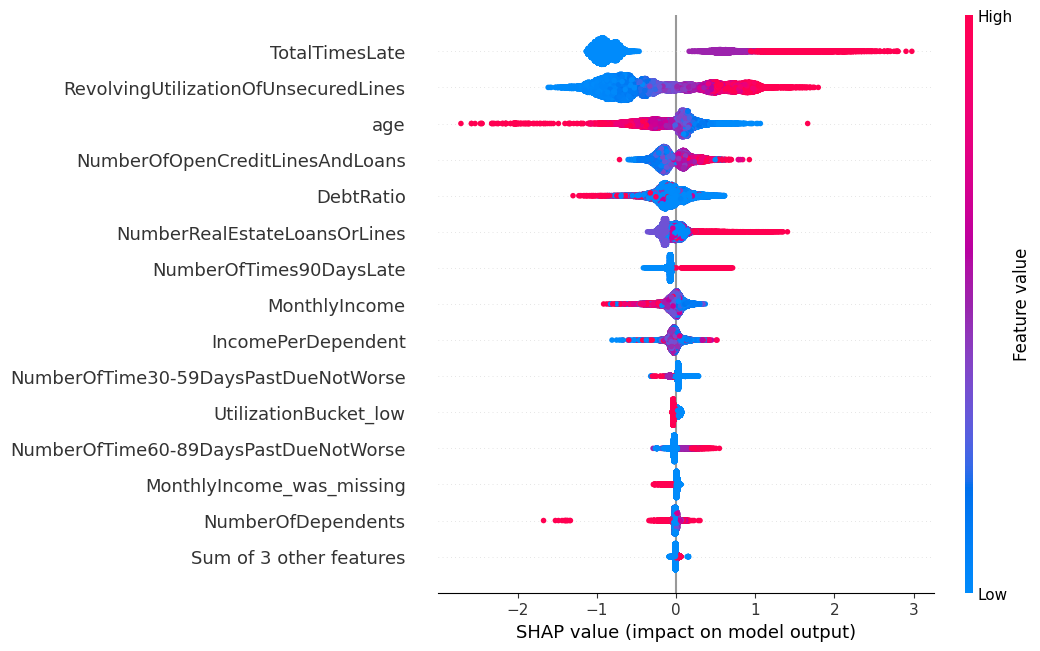

In [8]:
shap.plots.beeswarm(shap_values, max_display=15)

From the beeswarm plot, we can see that the features with the widest spread of SHAP values are `TotalTimesLate`, `RevolvingUtilizationOfUnsecuredLines`, `age`. For `TotalTimesLate`, the direction shows that the more times applicants are late, the more likely they are to default on a loan. `RevolvingUtilizationOfUnsecuredLines`'s direction shows that more utilization of unsecured lines, the more likely to default on a loan. `age` is interesting the direction shows that age is likely to predict loans default.

## 5. Global feature importance - bar chart
Below is a simplier alternative to the beeswarm: mean absolute SHAP value per feature is easier to read at a glance or drop into slides for non-technical audiences.

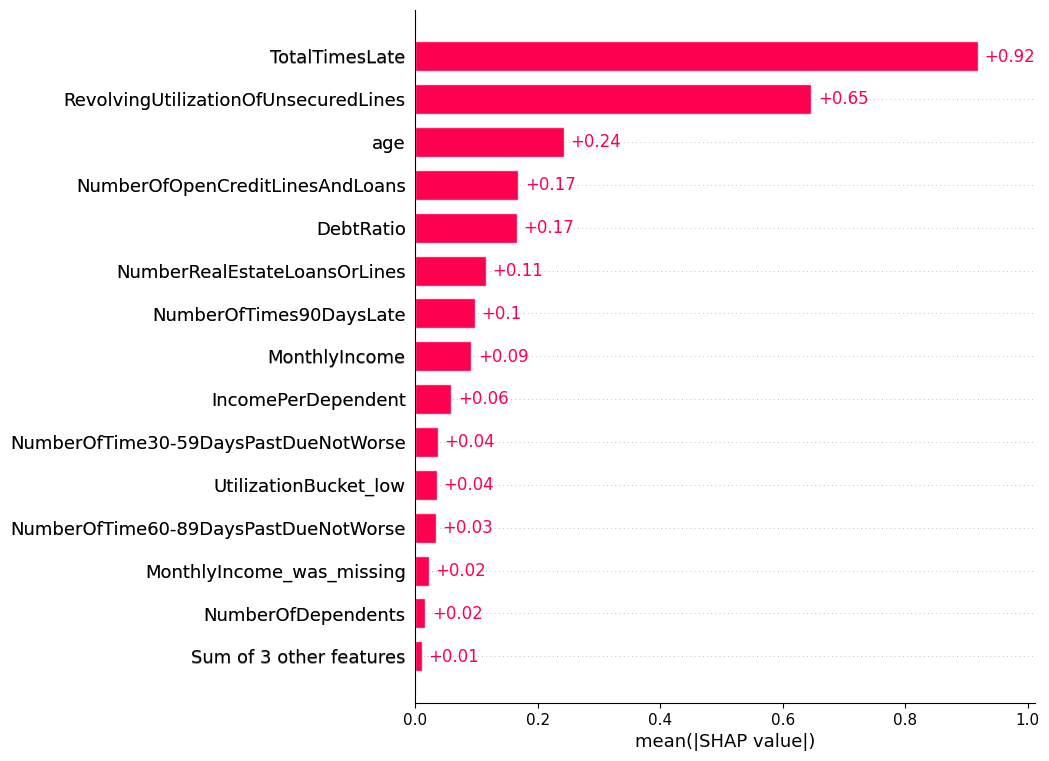

In [9]:
shap.plots.bar(shap_values, max_display=15)

## Local explanation - one deined applicant
Pick a high-risk prediction (model prediction high default probability) and show exactly which features drove that specific prediction - this is the "why was this applicant denied" answer a real credit system would need to produce.

In [10]:
probas = model.predict_proba(X_sample)[:,1]
high_risk_idx = int(np.argmax(probas))
print(f"Selected applicant - predicted default probability: {probas[high_risk_idx]:.3f}")
X_sample.iloc[high_risk_idx]

Selected applicant - predicted default probability: 0.989


RevolvingUtilizationOfUnsecuredLines    1.926948
age                                    -1.511999
NumberOfTime30-59DaysPastDueNotWorse    1.847255
DebtRatio                              -0.339835
MonthlyIncome                          -0.283985
NumberOfOpenCreditLinesAndLoans         0.492202
NumberOfTimes90DaysLate                 6.152628
NumberRealEstateLoansOrLines           -0.897940
NumberOfTime60-89DaysPastDueNotWorse    2.675753
NumberOfDependents                      2.946644
MonthlyIncome_was_missing              -0.496719
TotalTimesLate                          3.903055
IncomePerDependent                     -0.481699
HasRealEstateLoan                      -1.293836
UtilizationBucket_high                  1.000000
UtilizationBucket_low                   0.000000
UtilizationBucket_medium                0.000000
Name: 25447, dtype: float64

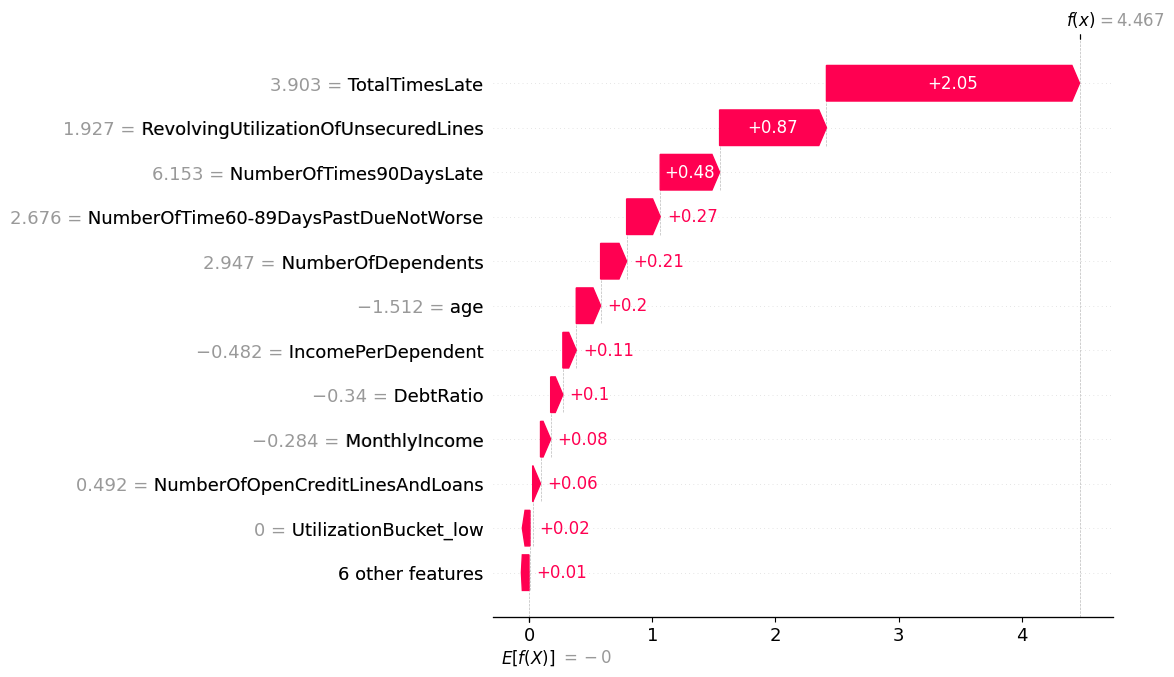

In [12]:
shap.plots.waterfall(shap_values[high_risk_idx], max_display=12)

For this particular applicant, the features that pushed them towards a default prediction were `TotalTimesLate` (3.9 times) with SHAP value of +2.05, the number of `RevolvingUtilizationOfUnsecuredLines` (1.9 times) with a SHAP value of +0.87, and the `NumberOfTimes90DaysLate` (6.2 times) with a SHAP value of 0.48.

## 7. Local explaination - one low risk applicant, for contrast
Showing both a high- and low-risk example makes the explaination more convincing than either alone - it demonstrates the model responds sensibly in both directions, not just it can point to some features

Selected applicant - predicted default probability: 0.002


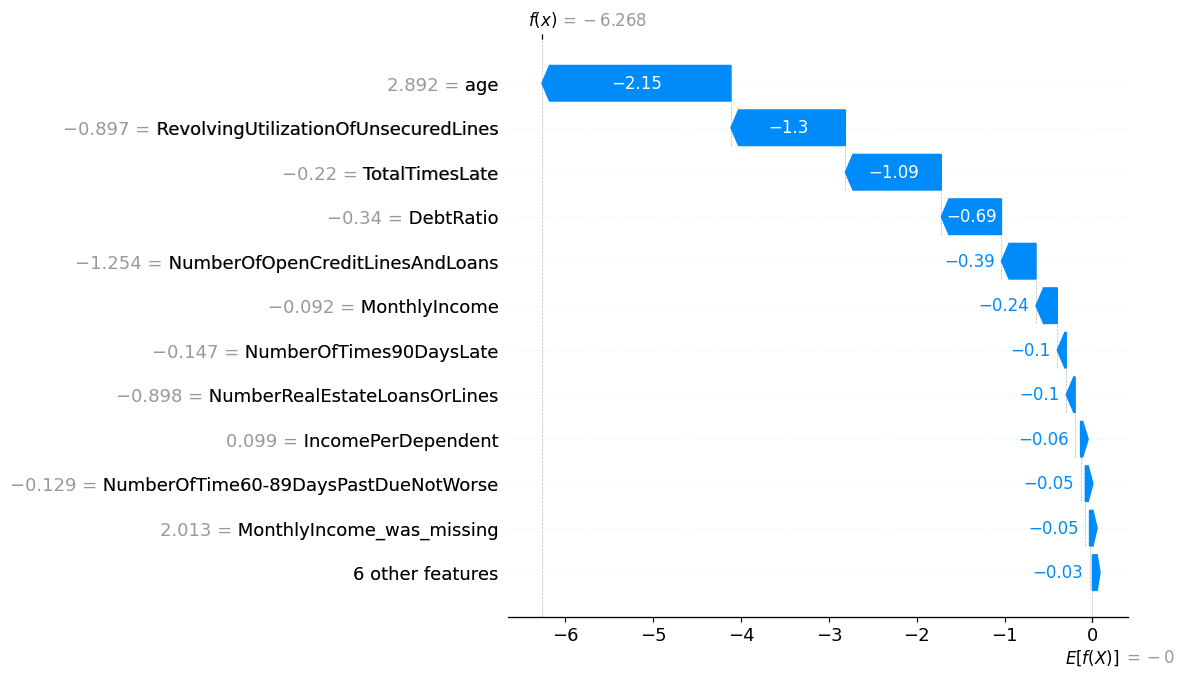

In [14]:
low_risk_idx = int(np.argmin(probas))
print(f"Selected applicant - predicted default probability: {probas[low_risk_idx]:.3f}")
shap.plots.waterfall(shap_values[low_risk_idx], max_display=12)

Checking an applicant who was less likely to default on the loan, we can see that `age`, `TotalTimesLate`, and `DebtRatio` are the top three features to predict whether this applicant wouldn't default on a loan. This particularly applicant had lower revolving utlization of unsecured lines and weren't late on payments. Their age seemed to be most important, it would be interesting to see if this applicant was slightly older or younger.

## 8. Sanity check against domain intuition
The top three global features seem to make intuitive sense for credit risk; if applicants are late on payments multiple times, there are more likely to default on their loans, if they have a higher revolving utilization of unsecured loans, which have more risk, they are more likely to default on their loans. Age seems to point to the applicant's age increasing their likelihood of defaulting on loans; maybe because younger applicants have less funds or less credit history than older applicants.

## 9. Summary
* Features that drove the model the most: `TotalTimesLate`, `RevolvingUtilizationOfUnsecuredLines`, and `age`
* These features seems to match domain intuition (applicants who are have been late on payments multiple times would increase their likelihood of defaulting on their loans, for example)
* This explainabilty is useful because it shows the *why* behind what the model would show, both globally and locally. Which mirrors the adverse notices common in credit risk settings